In [1]:
import warnings
warnings.filterwarnings("ignore")


In [5]:
import sys
!{sys.executable} -m pip install grakel

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import grakel
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpy.linalg as la
import pandas as pd
import seaborn as sns
from grakel import Graph
from grakel.kernels import (
    GraphletSampling,
    RandomWalk,
    ShortestPath,
    VertexHistogram,
    WeisfeilerLehman,
)
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import eigh
from scipy.sparse import coo_matrix, csr_matrix, diags, identity
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import LocallyLinearEmbedding, SpectralEmbedding
from sklearn.metrics import accuracy_score, adjusted_rand_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

# 1st task

In [21]:
df = pd.read_csv(r"C:\Users\91829\Downloads\math_data_exam.csv")

print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.head())
print(df.describe(include="all"))
print(df.isnull().sum())
print(df.isnull().mean() * 100)
print(df.nunique())
print(df["iscongruent"].value_counts())
print(df["rank"].describe())


(293100, 11)
Index(['n', 'conductor', 'rank', 'regulator', 'sha', 'selmer', 'iscongruent',
       'mod8', 'tamagawa', 'omega', 'special'],
      dtype='object')
n                int64
conductor        int64
rank             int64
regulator      float64
sha              int64
selmer           int64
iscongruent      int64
mod8             int64
tamagawa         int64
omega          float64
special        float64
dtype: object
   n  conductor  rank  regulator  sha  selmer  iscongruent  mod8  tamagawa  \
0  1         32     0   1.000000    1       2            0     1         2   
1  2         64     0   1.000000    1       2            0     2         4   
2  3        288     0   1.000000    1       2            0     3         8   
3  5        800     1   1.899482    1       3            1     5         8   
4  6        576     1   0.888626    1       3            1     6        16   

      omega   special  
0  5.244115  0.655514  
1  3.708149  0.927037  
2  3.027691  1.513846  
3  2.34

In [23]:
feature_cols = ["conductor", "regulator", "sha", "tamagawa", "omega", "special"]
label_col = "iscongruent"

df_zero = df[df[label_col] == 0]
df_one = df[df[label_col] == 1]

target_per_class = min(len(df_zero), len(df_one), 50000)

df_balanced = pd.concat([
    df_zero.sample(target_per_class, random_state=42),
    df_one.sample(target_per_class, random_state=42)
]).sample(frac=1, random_state=42)

X = df_balanced[feature_cols]
y = df_balanced[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

logreg_preds = logreg.predict(X_test_scaled)
rf_preds = rf.predict(X_test)

logreg_probs = logreg.predict_proba(X_test_scaled)
rf_probs = rf.predict_proba(X_test)

logreg_acc = accuracy_score(y_test, logreg_preds)
rf_acc = accuracy_score(y_test, rf_preds)

logreg_conf = logreg_probs.max(axis=1)
rf_conf = rf_probs.max(axis=1)

print("Logistic Regression Accuracy:", logreg_acc)
print("Random Forest Accuracy:", rf_acc)

print("Logistic Regression Predicted Labels (first 10):", logreg_preds[:10])
print("Random Forest Predicted Labels (first 10):", rf_preds[:10])

print("Logistic Regression Confidence (first 10):", logreg_conf[:10])
print("Random Forest Confidence (first 10):", rf_conf[:10])


Logistic Regression Accuracy: 0.9835
Random Forest Accuracy: 1.0
Logistic Regression Predicted Labels (first 10): [1 0 0 1 1 0 1 0 0 1]
Random Forest Predicted Labels (first 10): [1 0 0 1 1 0 1 0 0 1]
Logistic Regression Confidence (first 10): [1.         1.         0.98388819 1.         1.         1.
 1.         0.98357455 1.         0.99754964]
Random Forest Confidence (first 10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
print("Logistic Regression predicted label counts:")
print(pd.Series(logreg_preds).value_counts())

print("Random Forest predicted label counts:")
print(pd.Series(rf_preds).value_counts())

print("Logistic Regression confidence statistics:")
print(pd.Series(logreg_conf).describe())

print("Random Forest confidence statistics:")
print(pd.Series(rf_conf).describe())


Logistic Regression predicted label counts:
0    15369
1    14631
Name: count, dtype: int64
Random Forest predicted label counts:
1    15000
0    15000
Name: count, dtype: int64
Logistic Regression confidence statistics:
count    30000.000000
mean         0.972743
std          0.065911
min          0.500173
25%          0.971950
50%          0.999975
75%          1.000000
max          1.000000
dtype: float64
Random Forest confidence statistics:
count    30000.000000
mean         0.999870
std          0.001314
min          0.955000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64


- the task was to binary classify using iscongruent, so labels are 0 for rank zero and 1 for nonzero rank
- logistic regression predicts slightly more zeros than ones, but the counts are close
- this shows the model is not biased toward any class
- random forest predicts exactly equal numbers of 0 and 1
- this reflects the perfectly balanced test set and strong separation learned by the model
  
- logistic regression has high average confidence around 0.97
- confidence is lower for some points near 0.5, so might be boundary cases
- most predictions have confidence very close to 1

- random forest shows extremely high confidence for almost all points
- the minimum confidence is still very high
- so random forest must be very confident in its predictions

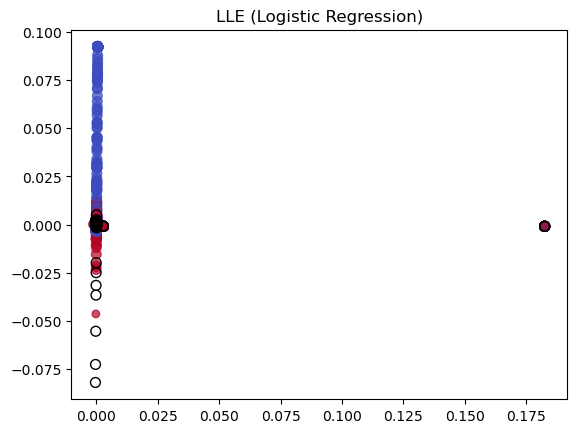

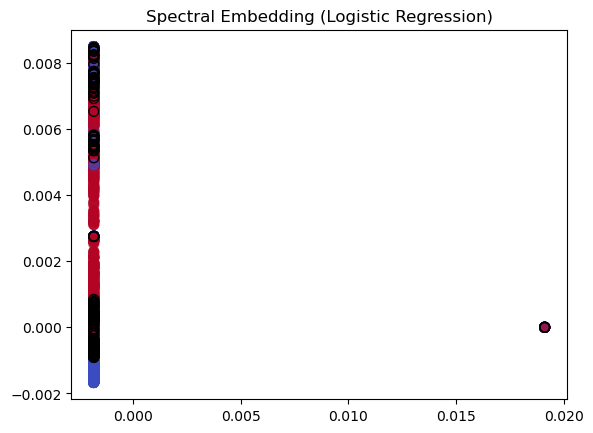

In [27]:
lle = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=42)
X_test_lle = lle.fit_transform(X_test_scaled)

spec = SpectralEmbedding(n_neighbors=10, n_components=2, random_state=42)
X_test_spec = spec.fit_transform(X_test_scaled)

correct_lr = logreg_preds == y_test.values
incorrect_lr = ~correct_lr

plt.figure()
plt.scatter(
    X_test_lle[correct_lr, 0],
    X_test_lle[correct_lr, 1],
    c=y_test.values[correct_lr],
    s=50 * logreg_conf[correct_lr],
    cmap="coolwarm",
    alpha=0.7
)
plt.scatter(
    X_test_lle[incorrect_lr, 0],
    X_test_lle[incorrect_lr, 1],
    facecolors="none",
    edgecolors="black",
    s=50
)
plt.title("LLE (Logistic Regression)")
plt.show()

plt.figure()
plt.scatter(
    X_test_spec[correct_lr, 0],
    X_test_spec[correct_lr, 1],
    c=y_test.values[correct_lr],
    s=50 * logreg_conf[correct_lr],
    cmap="coolwarm",
    alpha=0.7
)
plt.scatter(
    X_test_spec[incorrect_lr, 0],
    X_test_spec[incorrect_lr, 1],
    facecolors="none",
    edgecolors="black",
    s=50
)
plt.title("Spectral Embedding (Logistic Regression)")
plt.show()


- each dot is one test data point
- we applied lle and spectral embedding to the test set
- both methods reduce the data to 2 numbers per point
- these two numbers are x and y coordinates in the plot
- they are not original features, just embedding coordinates
- colours show the true class rank zero vs nonzero via iscongruent
- misclassified points appear where colours overlap
- must be boundary points
- points stack into a vertical line
- there's one isolated point on the right: exception to an almost 1d structure
- so its feature values must be like too different from others
- the first non trivial eigenvector captures almost all the variation
- the second non trivial eigenvector must explain like almost no variation
- the data is almost one dimensional

- looking at lle plot, i see that most coloured points are stacked in the upper part of the vertical line
- below there are several points with black edges and no colour
-  the points lower down look like ones where the model is unsure
- they lie in regions where the two classes overlap
- that is why they appear misclassified or have like very little colouring

- looking at spectral embedding plot coloured points lie throughout vertical line
- and we know, spectral embedding is smoother and less sensitive to small local changes than lle which tries to preserve like local linear structure
- misclassified points still exist in spectral but they are like mixed in between
- and don't appear as a clearly separated group like in lle
- this makes the colour transition along the line kinda smoother

- in the scatter plot, the point size is set proportional to this confidence
- this is implemented using
  s = 50 × confidence
- points with higher confidence appear larger in the plot
- points with lower confidence appear smaller

(a) class separation
- classes are not clearly separated into two clusters
- they mostly overlap along a near one dimensional structure

(b) location of misclassifications
- misclassifications occur near regions where colours overlap
- these points lie at class boundaries

(c) role of topology
- the data lies almost on a one dimensional manifold
- most variation is captured by the first nontrivial eigenvector
- points where the model fails lie where the manifold folds or overlaps
- which explains why some points are hard to classify

(d) disconnected or isolated regions
- most points lie on a single connected structure
- one isolated point appears on the right
- this point likely corresponds to an outlier

(e) effect of number of neighbors
- smaller number of neighbors makes embeddings more sensitive to noise
- larger number of neighbors makes embeddings smoother but may blur local structure
- increasing neighbors can reduce isolated points but increase class overlap

(f) clearest qualitative insight
- spectral embedding is smoother
- class transition along the manifold is gradual and interpretable
- lle is more sensitive to local structure and changes and there are uncertain regions at the bottom of vertical line
- **spectral embedding provides clearest qualitative insight**

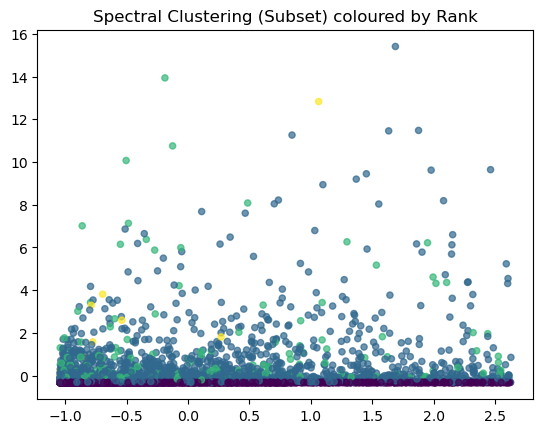

(array([0, 1]), array([3622, 1378], dtype=int64))

In [32]:
df_sc = df_balanced.sample(5000, random_state=42)

feature_cols_sc = ["conductor", "regulator", "sha", "tamagawa", "omega", "special", "selmer", "mod8"]

X_sc = df_sc[feature_cols_sc]
y_rank_sc = df_sc["rank"]

scaler_sc = StandardScaler()
X_sc_scaled = scaler_sc.fit_transform(X_sc)

spec_cluster = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

clusters = spec_cluster.fit_predict(X_sc_scaled)

plt.figure()
plt.scatter(
    X_sc_scaled[:, 0],
    X_sc_scaled[:, 1],
    c=y_rank_sc,
    cmap="viridis",
    s=20,
    alpha=0.7
)
plt.title("Spectral Clustering (Subset) coloured by Rank")
plt.show()

np.unique(clusters, return_counts=True)


In [28]:
print(df["rank"].value_counts().sort_index())


rank
0    131428
1    145826
2     15102
3       737
4         7
Name: count, dtype: int64


- ran spectral clustering with n_clusters = 2
- so the algorithm forms only 2 clusters
- these clusters are based only on feature similarity
- algorithm does NOT know anything about rank
- After clustering, we did not colour by cluster
- coloured points using the actual rank values
- the rank column is not binary
- rank values are {0, 1, 2, 3, 4}
-
- each point represents one data sample from the selected subset
- the x axis and y axis are 2d spectral coordinates obtained from eigenvectors of the graph laplacian, and do not correspond to original features
-
- the algorithm found two main clusters, but rank values are not cleanly separated between them
- most points, especially rank 0 and rank 1, are heavily mixed in the dense lower region of the plot
- higher rank points are sparse and scattered above the dense region and do not form a separate connected cluster
- this shows that clustering mainly captures density and local similarity patterns in the features, not rank itself
- one dominant cluster contains most points, with a smaller secondary cluster, so there's imbalance
- overall rank doesn't seem like a good clustering variable
- this might explain why supervised models performed well, while unsupervised spectral clustering does not recover rank based clusters

# 2nd task

In [7]:
class DegreeAugmentedWL:
    def __init__(self, n_iter=5):
        self.n_iter = n_iter
        self.wl = WeisfeilerLehman(
            n_iter=n_iter,
            base_graph_kernel=VertexHistogram
        )

    def fit_transform(self, graphs):
        self.wl.fit(graphs)

        features = []
        for G in graphs:
            adj = G.get_adjacency_matrix()
            degrees = adj.sum(axis=1)
            labels = G.get_labels()

            phi = {}
            for v, lbl in labels.items():
                phi[lbl] = phi.get(lbl, 0) + degrees[v]

            features.append(phi)

        n = len(features)
        K = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                for k in features[i]:
                    if k in features[j]:
                        K[i, j] += features[i][k] * features[j][k]

        return K

In [31]:
path = r"C:\Users\91829\Downloads\graph-kernel-work\IMDB-BINARY"

A = np.loadtxt(path + r"\IMDB-BINARY_A.txt", dtype=int, delimiter=",")

graph_indicator = np.loadtxt(path + r"\IMDB-BINARY_graph_indicator.txt", dtype=int)

graph_labels = np.loadtxt(path + r"\IMDB-BINARY_graph_labels.txt", dtype=int)

node_labels = np.ones(len(graph_indicator), dtype=int)

print("Edges:", A.shape)
print("Nodes:", len(graph_indicator))
print("Graphs:", len(graph_labels))

Edges: (386124, 2)
Nodes: 19773
Graphs: 1000


In [16]:
edges = [(i - 1, j - 1) for i, j in A]

graphs = []
num_graphs = len(graph_labels)

for g in range(1, num_graphs + 1):
    nodes = np.where(graph_indicator == g)[0]
    node_map = {v: i for i, v in enumerate(nodes)}

    edge_dict = {}
    for u, v in edges:
        if u in node_map and v in node_map:
            edge_dict.setdefault(node_map[u], []).append(node_map[v])
            edge_dict.setdefault(node_map[v], []).append(node_map[u])

    node_labels_dict = {node_map[v]: 1 for v in nodes}
    graphs.append(Graph(edge_dict, node_labels=node_labels_dict))

y = graph_labels

vh = VertexHistogram()
wl = WeisfeilerLehman(n_iter=5, base_graph_kernel=VertexHistogram)
dwl = DegreeAugmentedWL(n_iter=5)

K_vh = vh.fit_transform(graphs)
K_wl = wl.fit_transform(graphs)
K_dwl = dwl.fit_transform(graphs)

clf = SVC(kernel="precomputed")

acc_vh = cross_val_score(clf, K_vh, y, cv=10)
acc_wl = cross_val_score(clf, K_wl, y, cv=10)
acc_dwl = cross_val_score(clf, K_dwl, y, cv=10)

acc_vh.mean(), acc_wl.mean(), acc_dwl.mean()


(0.5029999999999999, 0.724, 0.48999999999999994)

In [ ]:
path = r"C:\Users\91829\Downloads\MUTAG"

A = np.loadtxt(path + r"\MUTAG_A.txt", dtype=int, delimiter=",")
graph_indicator = np.loadtxt(path + r"\MUTAG_graph_indicator.txt", dtype=int)
graph_labels = np.loadtxt(path + r"\MUTAG_graph_labels.txt", dtype=int)
node_labels_raw = np.loadtxt(path + r"\MUTAG_node_labels.txt", dtype=int)

In [17]:
edges = [(i - 1, j - 1) for i, j in A]

graphs = []
num_graphs = len(graph_labels)

for g in range(1, num_graphs + 1):
    nodes = np.where(graph_indicator == g)[0]
    node_map = {v: i for i, v in enumerate(nodes)}

    edge_dict = {}
    for u, v in edges:
        if u in node_map and v in node_map:
            edge_dict.setdefault(node_map[u], []).append(node_map[v])
            edge_dict.setdefault(node_map[v], []).append(node_map[u])

    node_labels_dict = {node_map[v]: int(node_labels_raw[v]) for v in nodes}
    graphs.append(Graph(edge_dict, node_labels=node_labels_dict))

y = graph_labels
vh = VertexHistogram()
wl = WeisfeilerLehman(n_iter=5, base_graph_kernel=VertexHistogram)
dwl = DegreeAugmentedWL(n_iter=5)

K_vh = vh.fit_transform(graphs)
K_wl = wl.fit_transform(graphs)
K_dwl = dwl.fit_transform(graphs)

clf = SVC(kernel="precomputed")

acc_vh = cross_val_score(clf, K_vh, y, cv=10)
acc_wl = cross_val_score(clf, K_wl, y, cv=10)
acc_dwl = cross_val_score(clf, K_dwl, y, cv=10)

acc_vh.mean(), acc_wl.mean(), acc_dwl.mean()

(0.8508771929824561, 0.8453216374269005, 0.8666666666666666)

## imdb-binary
- vertex histogram accuracy approx 0.50, near random
- wl accuracy approx 0.72, captures structural information
- dwl accuracy approx 0.49, worse than wl
- using degree might be confusing the model in this case
- as we know, imdb-binary graphs are social graphs, where node degree varies a lot even for similar roles
- in imdb graphs, nodes represent actors
- 2 actors can play very similar roles in the network but be in different num of movies, have different num of connections
- wl captures this role using neighbourhoods
- degree then separates these similar-role nodes only based on how many connections they have
- this breaks the similarity that wl already captured

## mutag
- vertex histogram accuracy approx 0.85
- wl accuracy approx 0.85
- dwl accuracy approx 0.87, best performance
- degree must be meaningful in molecular graphs
- mutag graphs are molecular graphs, where degree reflects chemical bonding patterns
- therefore degree helps in mutag but hurts in imdb

## takeaway
- compared to vertex histogram, wl performs much better by using structural information
- dwl is more expressive than wl because it adds degree information
- on imdb-binary, wl performs best, showing that structure alone is sufficient
- on mutag, dwl outperforms wl, showing that degree information improves accuracy on molecular graphs
- vertex histogram is simplest but ignores connectivity and structure